In [1]:
import numpy as np
import pandas as pd
from scipy.stats import zscore

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer

## Part 1: Features Setup/Further Refining of Data

In [2]:
final_df = pd.read_csv('./data/finalCards.csv')
# color 'U' is Blue, 'B' is Black

final_df.columns

Index(['uuid', 'cardName', 'availability', 'colorIdentity', 'defense',
       'edhrecRank', 'edhrecSaltiness', 'finishes', 'isAlternative',
       'isGameChanger', 'isPromo', 'isReprint', 'isReserved', 'keywords',
       'layout', 'loyalty', 'manaCost', 'manaValue', 'cardNumber', 'power',
       'rarity', 'setCode', 'subtypes', 'supertypes', 'text', 'toughness',
       'types', 'variations', 'price', 'commander', 'setName', 'releaseDate',
       'scryfallId', 'tcgplayerProductId', 'multiverseId', 'isHuman',
       'isElemental', 'isDragon', 'isSpirit', 'isAngel', 'isElf', 'isVampire',
       'isZombie', 'isBeast', 'isEldrazi', 'isWizard', 'isSoldier', 'isKnight',
       'isCleric', 'isWarrior', 'isRogue', 'isShaman', 'isDruid', 'isCreature',
       'isPlaneswalker', 'isMTGO', 'isLegal', 'isBanned', 'isBattle',
       'isFlying'],
      dtype='str')

In [3]:
# replace categorical with numbers
# 0.5 are special cases
final_df.commander = final_df.commander.map({'NotLegal':0, 'Banned':0.5, 'Legal':1})
final_df.rarity = final_df.rarity.map({'common':0, 'special':0.5, 'uncommon':1, 'rare':2, 'mythic':3})
final_df = final_df.replace({True: 1, False: 0})

#so it doesn't split words into individual letters
final_df.colorIdentity = final_df.colorIdentity.str.replace(',', '')

In [4]:
boolean_features = ['isAlternative','isGameChanger','isPromo','isReprint',
                    'isReserved','isHuman','isElemental', 'isDragon', 
                    'isSpirit', 'isAngel', 'isElf', 'isVampire',
                    'isZombie', 'isBeast', 'isEldrazi', 'isWizard', 
                    'isSoldier', 'isKnight','isCleric', 'isWarrior', 
                    'isRogue', 'isShaman', 'isDruid', 'isCreature',
                    'isPlaneswalker', 'isMTGO', 'isLegal', 'isBanned', 
                    'isBattle']

final_df[boolean_features] = final_df[boolean_features].apply(pd.to_numeric, axis=1)


In [5]:
noncreature_df = final_df.copy()
noncreature_df = noncreature_df[(noncreature_df['isCreature'] != 1)] #  & (noncreature_df['isReprint'] == 0)
noncreature_df = noncreature_df[[
       'uuid', 'cardName', 'availability', 'colorIdentity',
       'edhrecRank', 'edhrecSaltiness', 'finishes', 'isAlternative',
       'isGameChanger', 'isPromo', 'isReserved', 'keywords',
       'layout', 'loyalty', 'manaValue', 'cardNumber', 'isReprint',
       'rarity', 'setCode', 'subtypes', 'supertypes', 'text',
       'types', 'price', 'commander', 'setName', 'releaseDate',
       'isPlaneswalker', 'isBattle', 'isFlying', 'isEldrazi'
       ]]

print(len(noncreature_df))

49287


In [6]:
planeswalker_df = final_df[(final_df['isPlaneswalker'] == True)] # & (final_df['isReprint'] == 0)
planeswalker_df = planeswalker_df.drop(columns=['variations', 'defense', 
                                                'power', 'toughness',
                                                'isLegal', 'isBanned',  
                                                'isEldrazi', 'manaCost',
                                                'isPlaneswalker', 'isMTGO'])
planeswalker_df.head()

,uuid,cardName,availability,colorIdentity,edhrecRank,edhrecSaltiness,finishes,isAlternative,isGameChanger,isPromo,isReprint,isReserved,keywords,layout,loyalty,manaValue,cardNumber,rarity,setCode,subtypes,supertypes,text,types,price,commander,setName,releaseDate,scryfallId,tcgplayerProductId,multiverseId,isHuman,isElemental,isDragon,isSpirit,isAngel,isElf,isVampire,isZombie,isBeast,isWizard,isSoldier,isKnight,isCleric,isWarrior,isRogue,isShaman,isDruid,isCreature,isBattle,isFlying
43,001e28fe-5bc1-57ef-9814-adc1195a297b,"Liliana, the Last Hope",paper,B,7063.0,0.26,foil,1.0,0.0,0.0,1.0,0.0,Mill,normal,3.0,3.0,573,3.0,2X2,Liliana,Legendary,[+1]: Up to one target creature gets -2/-1 unt...,Planeswalker,22.3125,1.0,Double Masters 2022,2022-07-08,d5e2a410-fca6-4d3d-9b6b-519a968e5e86,276371.0,572991.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
85,00396ed6-b91d-5c78-8760-bb22d8f3e9ca,"Tevesh Szat, Doom of Fools","mtgo, paper",B,3174.0,0.57,"nonfoil, foil",0.0,0.0,0.0,0.0,0.0,Partner,normal,4.0,5.0,512,3.0,CMR,Szat,Legendary,[+2]: Create two 0/1 black Thrull creature tok...,Planeswalker,8.5025,1.0,Commander Legends,2020-11-20,2f68b4de-271b-415f-ad8f-104981bb12ab,226126.0,500770.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
87,003d9ecd-53bc-55c7-993f-26ec405f71e4,"Gideon, Martial Paragon","mtgo, paper",W,15747.0,0.37,foil,0.0,0.0,0.0,0.0,0.0,NoKeywords,normal,5.0,5.0,270,3.0,AKH,Gideon,Legendary,[+2]: Untap all creatures you control. Those c...,Planeswalker,1.1640,1.0,Amonkhet,2017-04-28,2c057ca8-9811-4dc3-9b0e-f9f69f752d1d,129826.0,429662.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
219,009c0efc-d03f-5a9d-8df9-d0fd2e94b4ca,"Liliana, Waker of the Dead",paper,B,5185.0,0.79,foil,1.0,0.0,1.0,1.0,0.0,NoKeywords,normal,4.0,4.0,108s,3.0,PM21,Liliana,Legendary,[+1]: Each player discards a card. Each oppone...,Planeswalker,5.4375,1.0,Core Set 2021 Promos,2020-07-03,97822ea2-162f-4e7d-9042-5ac4c258275b,217358.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
281,00be1adb-2ca4-5485-ba27-94f0e96eb2d9,"Minsc & Boo, Timeless Heroes",paper,G R,3343.0,0.54,foil,1.0,0.0,1.0,1.0,0.0,NoKeywords,normal,3.0,4.0,285s,3.0,PCLB,Minsc,Legendary,When Minsc & Boo enters and at the beginning o...,Planeswalker,11.8100,1.0,Battle for Baldur's Gate Promos,2022-06-10,e2d692c7-99cd-4602-8925-e2ac833d416b,274535.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


In [7]:
print(len(planeswalker_df))
planeswalker_df.isna().sum()

1324


uuid                     0
cardName                 0
availability             0
colorIdentity            0
edhrecRank              15
edhrecSaltiness         47
finishes                 0
isAlternative            0
isGameChanger            0
isPromo                  0
isReprint                0
isReserved               0
keywords                 0
layout                   0
loyalty                 20
manaValue                0
cardNumber               0
rarity                   0
setCode                  0
subtypes                 0
supertypes               0
text                     0
types                    0
price                    0
commander                0
setName                  0
releaseDate              0
scryfallId               0
tcgplayerProductId      19
multiverseId           614
isHuman                 17
isElemental             17
isDragon                17
isSpirit                17
isAngel                 17
isElf                   17
isVampire               17
i

In [8]:
creature_df = final_df.copy()
creature_df = creature_df[(creature_df['isCreature'] == 1)] #  & (creature_df['isReprint'] == 0)
creature_df = creature_df[['availability', 'cardName', 'colorIdentity',
       'edhrecRank', 'edhrecSaltiness', 'finishes', 'isAlternative',
       'isGameChanger', 'isPromo', 'isReserved', 'keywords',
       'manaValue', 'power', 'rarity', 'subtypes', 'isReprint',
       'supertypes', 'toughness', 'types', 'price', 'commander', 'isHuman',
       'isElemental', 'isDragon', 'isSpirit', 'isAngel', 'isElf', 'isVampire',
       'isZombie', 'isBeast', 'isWizard', 'isSoldier', 'isKnight', 'isCleric',
       'isWarrior', 'isRogue', 'isShaman', 'isDruid', 'isCreature',
       'isPlaneswalker', 'isFlying', 'isBattle', 'isEldrazi', 'text']]

# text, cardName, scryfall ids
# colorless pips (diamond) vs. generics pips (circles w/numbers in them)

creature_df.isna().sum()

availability           0
cardName               0
colorIdentity          0
edhrecRank           627
edhrecSaltiness     6833
finishes               0
isAlternative          0
isGameChanger          0
isPromo                0
isReserved             0
keywords               0
manaValue              0
power                711
rarity                 0
subtypes               0
isReprint              0
supertypes             0
toughness            576
types                  0
price                  0
commander              0
isHuman                4
isElemental            4
isDragon               4
isSpirit               4
isAngel                4
isElf                  4
isVampire              4
isZombie               4
isBeast                4
isWizard               4
isSoldier              4
isKnight               4
isCleric               4
isWarrior              4
isRogue                4
isShaman               4
isDruid                4
isCreature             0
isPlaneswalker         0


In [9]:
# A lot of cards that are really cheap
# but quite a few expensive ones too

def priceOutlier(df):
    df['Zscore'] = zscore(df['price'])

    no_outliers = df[df['Zscore'].abs() <= 3]
    no_outliers = no_outliers.drop(columns=['Zscore'])
    print(len(df), len(no_outliers))

    return no_outliers

In [10]:
noncreature_df = priceOutlier(noncreature_df)
noncreature_df['price'].sort_values(ascending=False)

49287 49190


59490    1540.355000
71830    1540.294000
51342    1522.516667
60377    1500.228000
885      1499.990000
            ...     
74074       0.095000
41696       0.090000
73087       0.030000
50670       0.030000
13008       0.020000
Name: price, Length: 49190, dtype: float64

In [11]:
planeswalker_df = priceOutlier(planeswalker_df)
planeswalker_df['price'].sort_values(ascending=False)

1324 1308


19504    155.6700
60577    152.2560
54737    134.0500
65110    132.1475
19403     92.3250
           ...   
85158      0.1975
26006      0.1820
26773      0.1820
57584      0.1780
88705      0.1600
Name: price, Length: 1308, dtype: float64

In [12]:
creature_df = priceOutlier(creature_df)
creature_df['price'].sort_values(ascending=False)

44836 44698


42088    369.745000
51810    369.440000
92798    364.281667
84971    360.890000
68518    350.714000
            ...    
831        0.090000
91830      0.082000
29011      0.030000
45825      0.030000
89391      0.020000
Name: price, Length: 44698, dtype: float64

In [13]:
def addTextFeatures(df, words):
    """
    df - pd.DataFrame containing MTG card data with ability text
    words - a list of words we wish to find and make into boolean features
    returns base df with new features (presence of the words in list 0/1)
    """
    for word in words:
        df['t_'+word] = df['text'].str.contains(word).fillna(0).astype(int)
    return df

In [14]:
creature_words = ["enters", "whenever", "spell", "flying", "end"]
creature_df = addTextFeatures(creature_df, creature_words)
creature_df.drop('text', axis=1, inplace=True)

creature_df.columns

Index(['availability', 'cardName', 'colorIdentity', 'edhrecRank',
       'edhrecSaltiness', 'finishes', 'isAlternative', 'isGameChanger',
       'isPromo', 'isReserved', 'keywords', 'manaValue', 'power', 'rarity',
       'subtypes', 'isReprint', 'supertypes', 'toughness', 'types', 'price',
       'commander', 'isHuman', 'isElemental', 'isDragon', 'isSpirit',
       'isAngel', 'isElf', 'isVampire', 'isZombie', 'isBeast', 'isWizard',
       'isSoldier', 'isKnight', 'isCleric', 'isWarrior', 'isRogue', 'isShaman',
       'isDruid', 'isCreature', 'isPlaneswalker', 'isFlying', 'isBattle',
       'isEldrazi', 't_enters', 't_whenever', 't_spell', 't_flying', 't_end'],
      dtype='str')

In [15]:
# add the following words as features based on ridge with tfidf model 
planeswalker_words = ["creature"]
planeswalker_df = addTextFeatures(planeswalker_df, planeswalker_words)
planeswalker_df.drop('text', axis=1, inplace=True)

planeswalker_df.columns

Index(['uuid', 'cardName', 'availability', 'colorIdentity', 'edhrecRank',
       'edhrecSaltiness', 'finishes', 'isAlternative', 'isGameChanger',
       'isPromo', 'isReprint', 'isReserved', 'keywords', 'layout', 'loyalty',
       'manaValue', 'cardNumber', 'rarity', 'setCode', 'subtypes',
       'supertypes', 'types', 'price', 'commander', 'setName', 'releaseDate',
       'scryfallId', 'tcgplayerProductId', 'multiverseId', 'isHuman',
       'isElemental', 'isDragon', 'isSpirit', 'isAngel', 'isElf', 'isVampire',
       'isZombie', 'isBeast', 'isWizard', 'isSoldier', 'isKnight', 'isCleric',
       'isWarrior', 'isRogue', 'isShaman', 'isDruid', 'isCreature', 'isBattle',
       'isFlying', 't_creature'],
      dtype='str')

In [16]:
# add the following words as features based on lasso with tfidf model 
noncreature_words = ["enters", "card", "target", "enchant creature", "enchant", "creature"]
noncreature_df = addTextFeatures(noncreature_df, noncreature_words)
noncreature_df.drop('text', axis=1, inplace=True)

noncreature_df.columns

Index(['uuid', 'cardName', 'availability', 'colorIdentity', 'edhrecRank',
       'edhrecSaltiness', 'finishes', 'isAlternative', 'isGameChanger',
       'isPromo', 'isReserved', 'keywords', 'layout', 'loyalty', 'manaValue',
       'cardNumber', 'isReprint', 'rarity', 'setCode', 'subtypes',
       'supertypes', 'types', 'price', 'commander', 'setName', 'releaseDate',
       'isPlaneswalker', 'isBattle', 'isFlying', 'isEldrazi', 't_enters',
       't_card', 't_target', 't_enchant creature', 't_enchant', 't_creature'],
      dtype='str')

## Part 2: Encoding

In [17]:
one_hot_encoding_creature_df = creature_df.copy()
one_hot_encoding_planeswalker_df = planeswalker_df.copy()
one_hot_encoding_noncreature_df = noncreature_df.copy()

In [18]:
def encodeFeatures(df):
    """
    df - a one-hot-encoded Pandas DataFrame
    with colorIdentity, availability, and finishes
    categorical variables with many different value combinations
    returns a concat-ed DataFrame of Multi-Binarized variables
    """
    df['colorIdentity'] = df['colorIdentity'].str.split()
    df['availability'] = df['availability'].str.replace(',', '')
    df['availability'] = df['availability'].str.split()
    df['finishes'] = df['finishes'].str.replace(',', '')
    df['finishes'] = df['finishes'].str.split()

    mlb = MultiLabelBinarizer()

    encoded_colors = mlb.fit_transform(df['colorIdentity'])
    colors_df = pd.DataFrame(encoded_colors, columns='c_'+mlb.classes_, index=df.index)
    colors_df = colors_df.drop(colors_df.columns[-1], axis=1)

    encoded_availability = mlb.fit_transform(df['availability'])
    availability_df = pd.DataFrame(encoded_availability, columns='a_'+mlb.classes_, index=df.index)
    availability_df = availability_df.drop(availability_df.columns[-1], axis=1)

    encoded_finishes = mlb.fit_transform(df['finishes'])
    finishes_df = pd.DataFrame(encoded_finishes, columns='f_'+mlb.classes_, index=df.index)
    finishes_df = finishes_df.drop(finishes_df.columns[-1], axis=1)

    features = pd.concat([colors_df, availability_df, finishes_df], axis=1) # keywords_df, subtypes_df
    print(features.columns)

    return features

In [19]:
creature_features = encodeFeatures(one_hot_encoding_creature_df)
noncreature_features = encodeFeatures(one_hot_encoding_noncreature_df)
planeswalker_features = encodeFeatures(one_hot_encoding_planeswalker_df)

Index(['c_B', 'c_Colorless', 'c_G', 'c_R', 'c_U', 'a_arena', 'a_mtgo',
       'f_etched', 'f_foil', 'f_nonfoil'],
      dtype='str')
Index(['c_B', 'c_Colorless', 'c_G', 'c_R', 'c_U', 'a_arena', 'a_mtgo',
       'f_etched', 'f_foil', 'f_nonfoil'],
      dtype='str')
Index(['c_B', 'c_Colorless', 'c_G', 'c_R', 'c_U', 'a_arena', 'a_mtgo',
       'f_etched', 'f_foil'],
      dtype='str')


In [20]:
creature_features

,c_B,c_Colorless,c_G,c_R,c_U,a_arena,a_mtgo,f_etched,f_foil,f_nonfoil
0,0,0,0,0,1,0,0,0,1,0
1,0,0,0,1,0,0,0,0,0,1
3,0,0,1,1,0,0,1,0,1,1
6,1,0,0,0,0,0,1,0,0,1
7,0,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
94113,0,0,0,0,0,0,1,0,0,1
94115,0,0,1,0,0,0,0,0,1,0
94116,0,0,1,1,0,0,0,0,0,1
94118,0,0,0,0,0,0,1,0,0,1


## Part 3: Consolidating Data

In [21]:
creatures_df = creature_df.copy()
creatures_df = creatures_df.join(creature_features)
creatures_df = creatures_df.drop(columns=['colorIdentity', 'availability', 'finishes'])

print(len(creatures_df))
creatures_df.isna().sum()

44698


cardName               0
edhrecRank           624
edhrecSaltiness     6814
isAlternative          0
isGameChanger          0
isPromo                0
isReserved             0
keywords               0
manaValue              0
power                706
rarity                 0
subtypes               0
isReprint              0
supertypes             0
toughness            572
types                  0
price                  0
commander              0
isHuman                4
isElemental            4
isDragon               4
isSpirit               4
isAngel                4
isElf                  4
isVampire              4
isZombie               4
isBeast                4
isWizard               4
isSoldier              4
isKnight               4
isCleric               4
isWarrior              4
isRogue                4
isShaman               4
isDruid                4
isCreature             0
isPlaneswalker         0
isFlying           18390
isBattle               0
isEldrazi              4


In [22]:
noncreatures_df = noncreature_df.copy()
noncreatures_df = noncreatures_df.join(noncreature_features)
noncreatures_df = noncreatures_df.drop(columns=['availability', 'finishes'])

print(len(noncreatures_df))
noncreatures_df.isna().sum()

49190


uuid                      0
cardName                  0
colorIdentity             0
edhrecRank             4918
edhrecSaltiness        5686
isAlternative             0
isGameChanger             0
isPromo                   0
isReserved                0
keywords                  0
layout                    0
loyalty               47886
manaValue                 0
cardNumber                0
isReprint                 0
rarity                    0
setCode                   0
subtypes                  0
supertypes                0
types                     0
price                     0
commander                 0
setName                   0
releaseDate               0
isPlaneswalker            0
isBattle                  0
isFlying              35423
isEldrazi             36029
t_enters                  0
t_card                    0
t_target                  0
t_enchant creature        0
t_enchant                 0
t_creature                0
c_B                       0
c_Colorless         

In [23]:
planeswalkers_df = planeswalker_df.copy()
planeswalkers_df = planeswalkers_df.join(planeswalker_features)
planeswalkers_df = planeswalkers_df.drop(columns=['availability', 'finishes'])
planeswalkers_df = planeswalkers_df.dropna(subset=['loyalty'])

print(len(planeswalkers_df))

1288


In [24]:
# some creatures have variable power and toughness
# that are represented as N/As
# A card not having an EDHREC rank usually means
# it doesn't exist in their database

no_var_pow_tough_all_edhrec = creatures_df.dropna(subset=['power','toughness','edhrecRank'])
noncreat_all_edhrec = noncreatures_df.dropna(subset=['edhrecRank'])
planeswalker_all_edhrec = planeswalkers_df.dropna(subset=['edhrecRank'])

In [25]:
mean_saltiness_creat = np.mean(no_var_pow_tough_all_edhrec.edhrecSaltiness)
no_var_pow_tough_all_edhrec.edhrecSaltiness = no_var_pow_tough_all_edhrec.edhrecSaltiness.fillna(mean_saltiness_creat)
print(mean_saltiness_creat)

mean_saltiness_noncreat = np.mean(noncreat_all_edhrec.edhrecSaltiness)
noncreat_all_edhrec.edhrecSaltiness = noncreat_all_edhrec.edhrecSaltiness.fillna(mean_saltiness_noncreat)
print(mean_saltiness_noncreat)

mean_saltiness_pw = np.mean(planeswalker_all_edhrec.edhrecSaltiness)
planeswalker_all_edhrec.edhrecSaltiness = planeswalker_all_edhrec.edhrecSaltiness.fillna(mean_saltiness_pw)
print(mean_saltiness_pw)

0.3573973007056803
0.36369290963356826
0.4948917401764234


In [26]:
# we could try looking at these later
variable_toughness = creatures_df[creatures_df['toughness'].isna()]
variable_toughness.edhrecSaltiness = variable_toughness.edhrecSaltiness.fillna(np.mean(variable_toughness.edhrecSaltiness))
variable_power = creatures_df[creatures_df['power'].isna()]
variable_power.edhrecSaltiness = variable_power.edhrecSaltiness.fillna(np.mean(variable_power.edhrecSaltiness))

In [27]:
# not needed
planeswalker_all_edhrec = planeswalker_all_edhrec.drop(columns=['commander','tcgplayerProductId','multiverseId'])

In [28]:
planeswalker_all_edhrec.select_dtypes(include='number').corr()

,edhrecRank,edhrecSaltiness,isAlternative,isGameChanger,isPromo,isReprint,isReserved,loyalty,manaValue,rarity,price,isHuman,isElemental,isDragon,isSpirit,isAngel,isElf,isVampire,isZombie,isBeast,isWizard,isSoldier,isKnight,isCleric,isWarrior,isRogue,isShaman,isDruid,isCreature,isBattle,t_creature,c_B,c_Colorless,c_G,c_R,c_U,a_arena,a_mtgo,f_etched,f_foil
edhrecRank,1.000000,-0.312631,-0.068043,-0.111107,-0.045055,-0.152656,NaN,-0.022154,0.046430,0.062612,-0.203460,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.080929,-0.080984,-0.186060,0.005899,0.211039,-0.051121,0.047350,0.019161,-0.030229,0.040835
edhrecSaltiness,-0.312631,1.000000,0.018407,0.370367,-0.025515,0.055909,NaN,0.141549,0.057051,-0.015949,0.204691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.159160,0.011431,0.357176,-0.131224,-0.114853,0.229146,-0.002026,0.028203,-0.004940,0.028078
isAlternative,-0.068043,0.018407,1.000000,-0.030691,0.311746,0.064384,NaN,0.004709,-0.015267,0.053257,0.077206,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.026580,-0.019652,0.019564,-0.002707,-0.034490,0.001978,-0.115144,-0.284533,0.010197,0.127558
isGameChanger,-0.111107,0.370367,-0.030691,1.000000,-0.025140,0.042911,NaN,0.059986,-0.084145,-0.202099,0.016593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.033503,-0.049749,-0.017004,-0.046583,-0.051969,0.118212,-0.003742,-0.002924,-0.009758,-0.020614
isPromo,-0.045055,-0.025515,0.311746,-0.025140,1.000000,0.368866,NaN,0.035858,-0.030308,-0.004867,0.198265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.045017,-0.009018,0.036215,0.014026,-0.024689,-0.019478,-0.361760,-0.611810,-0.073733,0.243094
isReprint,-0.152656,0.055909,0.064384,0.042911,0.368866,1.000000,NaN,0.008483,-0.043684,-0.067982,0.088476,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.085063,-0.011328,0.052971,0.000037,-0.032395,-0.037493,-0.638450,-0.568745,-0.034773,-0.249372
isReserved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loyalty,-0.022154,0.141549,0.004709,0.059986,0.035858,0.008483,NaN,1.000000,0.585856,-0.228326,0.027743,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.011582,0.026738,0.226765,-0.082941,0.025389,-0.099168,0.024186,-0.056955,-0.028605,0.005512
manaValue,0.046430,0.057051,-0.015267,-0.084145,-0.030308,-0.043684,NaN,0.585856,1.000000,0.107441,-0.006597,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.019172,0.077091,0.212988,-0.041253,0.002639,-0.138729,0.015504,0.032336,-0.001056,-0.020728
rarity,0.062612,-0.015949,0.053257,-0.202099,-0.004867,-0.067982,NaN,-0.228326,0.107441,1.000000,0.140000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.064939,0.049006,-0.002273,-0.022843,0.008327,-0.003554,0.020213,0.119269,-0.008241,0.062724


In [29]:
no_var_pow_tough_all_edhrec.select_dtypes(include='number').corr()

,edhrecRank,edhrecSaltiness,isAlternative,isGameChanger,isPromo,isReserved,manaValue,power,rarity,isReprint,toughness,price,commander,isHuman,isElemental,isDragon,isSpirit,isAngel,isElf,isVampire,isZombie,isBeast,isWizard,isSoldier,isKnight,isCleric,isWarrior,isRogue,isShaman,isDruid,isCreature,isPlaneswalker,isBattle,isEldrazi,t_enters,t_whenever,t_spell,t_flying,t_end,c_B,c_Colorless,c_G,c_R,c_U,a_arena,a_mtgo,f_etched,f_foil,f_nonfoil
edhrecRank,1.000000,-0.201768,-0.115773,-0.049631,-0.179016,0.100700,-0.044088,-0.064383,-0.512363,-0.180538,-0.106740,-0.129956,-0.095954,0.017249,0.032534,-0.078669,0.033270,-0.057678,-0.073630,-0.044880,0.015876,0.057820,-0.039400,0.083944,0.009786,0.001745,0.038055,-0.018171,-0.037074,-0.094558,NaN,NaN,NaN,-0.041399,-0.101034,-0.018858,-0.124662,0.042378,0.067318,-0.046779,-0.044878,-0.084960,0.022300,-0.021650,-0.076820,0.043539,-0.096797,-0.054276,0.173312
edhrecSaltiness,-0.201768,1.000000,0.059511,0.264783,0.045662,-0.008406,0.171939,0.163220,0.268519,0.039756,0.172995,0.191834,0.008613,0.020814,-0.008847,0.030913,-0.002105,0.032686,-0.027419,-0.007944,-0.023586,-0.006828,0.039410,-0.022423,-0.022458,0.002197,-0.022151,0.006943,-0.019117,-0.025582,NaN,NaN,NaN,0.094779,-0.027906,0.011852,0.073032,-0.050008,-0.024942,0.064154,0.016211,0.015194,0.016743,0.074408,-0.026521,-0.040641,0.068000,0.071532,-0.110313
isAlternative,-0.115773,0.059511,1.000000,-0.000354,0.307747,-0.012587,-0.003677,0.034574,0.164591,0.028530,0.038353,0.146164,-0.041665,0.019523,-0.018534,0.004103,-0.017429,-0.001466,-0.009780,-0.003768,-0.013119,-0.012930,-0.006933,-0.005974,0.022356,0.007197,-0.006033,0.014290,-0.025252,-0.006698,NaN,NaN,NaN,-0.006228,0.018163,0.015134,0.036039,-0.011906,0.015499,0.024625,-0.010679,0.009713,0.029086,0.033695,-0.063890,-0.230045,-0.021111,0.139526,-0.546831
isGameChanger,-0.049631,0.264783,-0.000354,1.000000,0.006529,-0.003080,0.006994,-0.008512,0.031276,0.017715,0.008079,0.054299,0.005146,0.017270,-0.007072,-0.006981,0.029237,-0.005733,-0.007993,-0.006592,-0.007311,-0.006115,0.016468,-0.008680,-0.006582,-0.007108,-0.009690,0.025576,-0.006768,-0.005942,NaN,NaN,NaN,-0.003658,-0.009779,0.049681,0.005878,-0.009474,-0.016432,0.006007,-0.007854,-0.006786,-0.021354,0.023574,-0.005274,-0.004738,0.010029,0.011978,-0.007394
isPromo,-0.179016,0.045662,0.307747,0.006529,1.000000,-0.022539,0.002197,0.071766,0.281413,0.266655,0.067867,0.040592,0.042386,0.008428,-0.004610,0.043135,-0.003424,0.018893,-0.001188,0.016221,-0.012179,-0.012408,0.010554,-0.025244,0.015065,0.009112,0.005582,0.006517,-0.014485,0.006722,NaN,NaN,NaN,0.018636,0.031076,0.005013,0.062773,-0.009511,0.013713,0.018752,-0.022652,0.026725,0.026207,0.013812,-0.158279,-0.408277,-0.041511,0.222088,-0.502685
isReserved,0.100700,-0.008406,-0.012587,-0.003080,-0.022539,1.000000,0.026294,0.001517,0.054345,-0.035423,0.004574,0.107454,-0.100563,-0.001118,-0.006544,0.001508,0.003418,-0.001559,-0.008206,-0.009756,-0.008838,-0.008336,-0.009577,-0.010421,0.000091,0.003989,-0.011190,-0.006696,-0.005484,-0.004203,NaN,NaN,NaN,-0.008134,-0.037378,0.007642,-0.022364,-0.002289,0.010981,-0.003826,0.008919,-0.010047,0.010364,0.002273,-0.044707,-0.053945,-0.010584,-0.105834,0.026343
manaValue,-0.044088,0.171939,-0.003677,0.006994,0.002197,0.026294,1.000000,0.721196,0.289483,0.016267,0.701128,0.048540,0.018235,-0.179864,0.083199,0.213931,0.009467,0.122224,-0.088162,-0.008167,-0.022656,0.089497,-0.061727,-0.071590,-0.029659,-0.077534,-0.046279,-0.065188,-0.051344,-0.080080,NaN,NaN,NaN,0.128001,0.084454,0.003528,0.091866,0.012574,-0.016745,0.030343,0.088858,0.029829,0.029858,0.044127,-0.057771,-0.009769,0.035835,-0.019299,-0.045027
power,-0.064383,0.163220,0.034574,-0.008512,0.071766,0.001517,0.721196,1.000000,0.301158,-0.004760,0.732667,0.055007,0.030701,-0.179764,0.087151,0.195900,0.001059,0.082132,-0.083965,-0.003111,-0.011261,0.096984,-0.097117,-0.067037,-0.008742,-0.089857,-0.002825,-0.058750,-0.061799,-0.086597,NaN,NaN,NaN,0.142201,0.003168,0.004247

In [30]:
noncreat_all_edhrec.select_dtypes(include='number').corr()

,edhrecRank,edhrecSaltiness,isAlternative,isGameChanger,isPromo,isReserved,loyalty,manaValue,isReprint,rarity,price,commander,isPlaneswalker,isBattle,isEldrazi,t_enters,t_card,t_target,t_enchant creature,t_enchant,t_creature,c_B,c_Colorless,c_G,c_R,c_U,a_arena,a_mtgo,f_etched,f_foil,f_nonfoil
edhrecRank,1.000000,-0.036099,-0.110778,-0.082741,-0.102029,0.095932,-0.023111,0.190441,-0.306051,-0.276623,-0.069068,-0.094037,-0.052346,0.004411,-0.052349,-0.174272,-0.054950,0.149586,-0.006742,0.073190,0.186924,-0.003455,-0.116241,-0.056277,0.017554,-0.030808,-0.021543,-0.004033,-0.061090,-0.007069,0.121195
edhrecSaltiness,-0.036099,1.000000,0.008730,0.344362,0.008346,0.086150,0.157738,0.239370,0.033765,0.219810,0.205632,-0.082769,0.072640,-0.005434,0.122450,-0.152701,-0.017660,-0.021650,0.009892,0.045775,-0.031496,-0.022161,0.040379,-0.092420,-0.054754,0.013912,-0.056544,-0.063401,0.043012,0.013383,-0.058724
isAlternative,-0.110778,0.008730,1.000000,-0.000294,0.254180,-0.023700,-0.000238,-0.033226,0.088276,0.150379,0.046568,-0.081819,0.034217,-0.009950,-0.017157,0.054909,0.019672,-0.027233,-0.004732,-0.016244,-0.028942,-0.010047,0.082274,-0.012479,-0.000897,-0.001697,-0.083913,-0.216020,-0.022741,0.147796,-0.539808
isGameChanger,-0.082741,0.344362,-0.000294,1.000000,0.006801,0.030617,0.059355,-0.017266,0.039390,0.066967,0.153504,-0.018912,-0.001044,-0.002821,-0.001582,-0.014899,0.051341,-0.036455,-0.002225,-0.003157,-0.059454,0.002725,0.009839,-0.013627,-0.023509,0.004917,-0.010151,-0.008973,0.026721,0.008450,-0.021494
isPromo,-0.102029,0.008346,0.254180,0.006801,1.000000,-0.029181,0.038789,0.068527,0.190415,0.281706,0.014987,0.059500,0.106752,0.025828,0.005731,0.039036,0.081755,0.017572,-0.005645,-0.007265,0.029222,0.027563,-0.016209,0.007623,0.014513,0.023280,-0.129947,-0.374796,-0.028059,0.230724,-0.496539
isReserved,0.095932,0.086150,-0.023700,0.030617,-0.029181,1.000000,NaN,-0.012638,-0.041704,0.079113,0.286939,-0.151223,-0.018768,-0.003723,-0.005239,-0.032928,-0.022312,-0.026930,-0.002937,0.018923,-0.040090,-0.004053,0.026453,-0.003498,-0.008477,-0.009256,-0.051297,-0.080056,-0.010485,-0.126304,0.036049
loyalty,-0.023111,0.157738,-0.000238,0.059355,0.038789,NaN,1.000000,0.591451,0.003856,-0.225658,0.003542,0.044736,NaN,NaN,NaN,0.062520,-0.071891,0.031067,NaN,0.023454,-0.000721,0.025144,0.241262,-0.089112,0.021068,-0.101612,0.028825,-0.054923,-0.028359,0.005603,-0.048083
manaValue,0.190441,0.239370,-0.033226,-0.017266,0.068527,-0.012638,0.591451,1.000000,-0.144829,0.235905,-0.039636,0.052811,0.154814,0.017446,0.100790,-0.246061,0.123237,0.116776,-0.001906,0.094422,0.211736,0.022384,-0.153343,-0.017058,0.016312,0.023938,0.028860,0.013304,0.009149,0.069523,-0.036604
isReprint,-0.306051,0.033765,0.088276,0.039390,0.190415,-0.041704,0.003856,-0.144829,1.000000,0.017336,0.027088,-0.127544,0.002012,-0.041969,0.014756,0.022750,-0.056643,-0.070557,0.003167,-0.049623,-0.156761,-0.002550,0.063259,0.014411,-0.012352,-0.005063,-0.362377,-0.378388,0.023293,-0.335819,-0.176139
rarity,-0.276623,0.219810,0.150379,0.066967,0.281706,0.079113,-0.225658,0.235905,0.017336,1.000000,0.117892,0.035088,0.276267,0.019008,0.026287,0.044985,0.104959,-0.069323,-0.005134,-0.009282,-0.006028,0.010159,0.094022,0.002821,0.018032,0.005290,0.005793,-0.081148,0.058202,0.155717,-0.265824


## Part 4: Model and Visualization

In [31]:
X_noncreat = noncreat_all_edhrec[
    [ # commented out features don't contribute much to price
        'edhrecRank',
        'edhrecSaltiness',
        'manaValue', 
        'rarity',
        #'commander',
        'isPromo',
        #'isReprint',
        'isAlternative',
        #'isPlaneswalker',
        #'isBattle',
        #'isFlying',
        #'isEldrazi',
        'c_Colorless', 
        #'c_B', 
        #'c_G',
        #'c_R', 
        #'c_U', 
        #'a_arena',
        'a_mtgo', 
        't_enters',
        't_card', 
        't_target', 
        't_enchant creature', 
        't_enchant', 
        't_creature',
        #'f_etched',
        #'f_foil'
        ]]

y_noncreat = noncreat_all_edhrec['price']

In [32]:
X_pw = planeswalker_all_edhrec[
    [
        'loyalty', 
        'edhrecRank',
        'edhrecSaltiness',
        'manaValue', 
        'rarity',
        #'commander',
        'isPromo',
        #'isAlternative',
        #'isReprint',
        'c_Colorless', 
        't_creature',
        #'c_B', 
        #'c_G',
        #'c_R', 
        #'c_U', 
        #'a_arena',
        #'a_mtgo', 
        #'f_etched', 
        #'f_foil'
        ]]

y_pw = planeswalker_all_edhrec['price']

In [33]:
X_creat = no_var_pow_tough_all_edhrec[
    [
        'power', 
        'toughness', 
        'edhrecRank',
        'edhrecSaltiness',
        'manaValue',
        'isAlternative',
        'isReprint',
        'isHuman', 
        'isElemental',
        'isDragon', 
        'isSpirit', 
        'isAngel', 
        'isElf',
        'isVampire', 
        'isZombie',
        'isBeast', 
        'isWizard', 
        'isSoldier', 
        'isKnight', 
        'isCleric', 
        'isWarrior',
        'isRogue', 
        'isShaman', 
        'isDruid', 
        #'isFlying',
        'isEldrazi',
        'c_Colorless', 
        'c_B', 
        'c_G',
        'c_R', 
        'c_U', 
        'a_arena',
        'a_mtgo', 
        'f_etched', 
        'f_foil',
        't_enters', 
        't_whenever', 
        't_spell', 
        't_flying', 
        't_end',
        'rarity',
        ]]

y_creat = no_var_pow_tough_all_edhrec['price']

In [36]:
X_train_creat, X_test_creat, y_train_creat, y_test_creat = train_test_split(X_creat, y_creat, test_size=0.2, random_state=42)
X_train_nc, X_test_nc, y_train_nc, y_test_nc = train_test_split(X_noncreat, y_noncreat, test_size=0.2, random_state=42)
X_train_pw, X_test_pw, y_train_pw, y_test_pw = train_test_split(X_pw, y_pw, test_size=0.2, random_state=42)

### Subtype, legality, etc.

In [43]:
def knnRegTest(X_train, X_test, y_train, y_test, graphtype):
    """
    X_train, X_test - dataframe
    y_train, y_test - series
    graphtype - string (planeswalker, noncreature, creature) for graph name
    displays a plot of error rate vs K-values
    """
    error_rate = []

    for i in range(1,40):
        knn = KNeighborsRegressor(n_neighbors=i)
        knn.fit(X_train, y_train)
        # testing the model
        pred_i = knn.predict(X_test)
        error_rate.append(np.mean(pred_i != y_test))
        
    # Configure and plot error rate over k values
    plt.figure(figsize=(10,4))
    plt.plot(range(1,40), error_rate, color='blue', linestyle='dashed', marker='o', markerfacecolor='green', markersize=10)

    #plotting knn graph
    plt.title(graphtype + ' Error Rate vs. K-Values')
    plt.xlabel('K-Values')
    plt.ylabel('Error Rate')

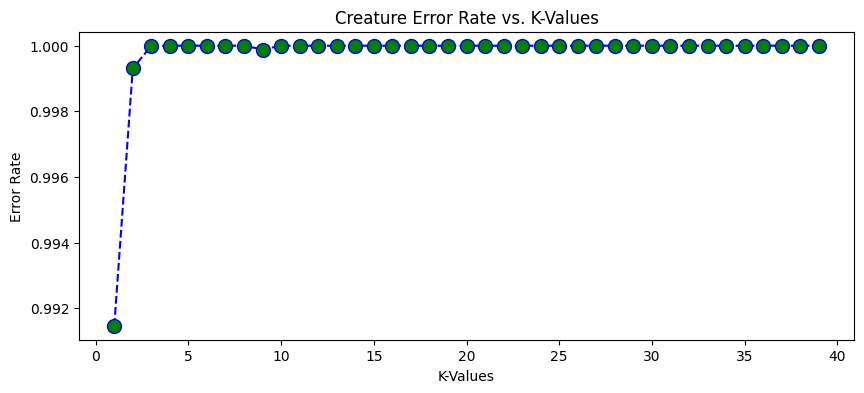

In [44]:
knnRegTest(X_train_creat, X_test_creat, y_train_creat, y_test_creat, graphtype='Creature')

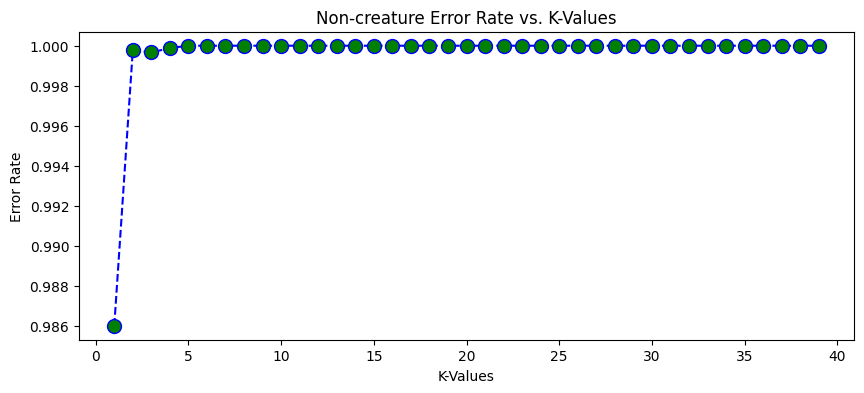

In [45]:
knnRegTest(X_train_nc, X_test_nc, y_train_nc, y_test_nc, graphtype='Non-creature')

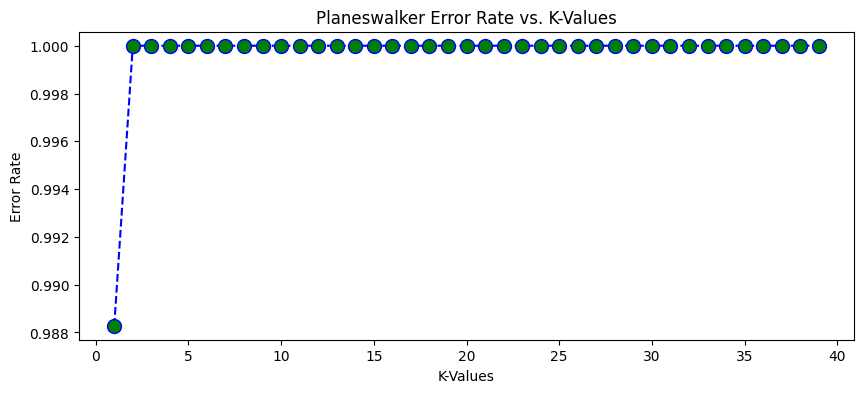

In [46]:
knnRegTest(X_train_pw, X_test_pw, y_train_pw, y_test_pw, graphtype='Planeswalker')

In [47]:
def gridSearchTest(X_train, y_train):
    """
    X_train - dataframe
    y_train - series
    displays best-performing hyperparameters and their score
    """
    
    grid_params = {'n_neighbors' : [5,7,9,11,13,15],
                'weights' : ['uniform','distance'],
                'metric' : ['minkowski','euclidean','manhattan']}

    # initializing KNN hyperparameter tuning
    gs = GridSearchCV(KNeighborsRegressor(), grid_params, verbose = 1, cv=5, n_jobs = -1)

    # fit on training set
    g_res = gs.fit(X_train, y_train)

    print(g_res.best_params_, g_res.best_score_)

In [48]:
gridSearchTest(X_train_creat, y_train_creat)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
{'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'} 0.03334037256471438


In [49]:
gridSearchTest(X_train_nc, y_train_nc)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
{'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'} 0.0811621776945601


In [50]:
gridSearchTest(X_train_pw, y_train_pw)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
{'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'} -0.007546844046611168


In [51]:
def knnReg(X_train, X_test, y_train, y_test, graphtype, n_neighbors=15, metric='manhattan'):
    """
    X_train, X_test - dataframes
    y_train, y_test - series
    graphtype - string (Creature, Noncreature, Planeswalker)
    n_neighbors - int of neighbors from testing
    metric - string, ideal metric for KNN

    returns MAE, MSE, R2 scores and displays graph
    """
    
    # standardize values for wildly different features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # initialize KNN with tuned hyperparameters  
    knn_regressor = KNeighborsRegressor(n_neighbors=n_neighbors, metric=metric)
    knn_regressor.fit(X_train, y_train)

    y_pred = knn_regressor.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print('Mean Absolute Error:', mae, ' ',
          'Mean Squared Error:', mse, ' ',
          'R2 Score:', r2)

    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2, label='Ideal fit')
    plt.title(graphtype + ' KNN Regression: Predicted vs Actual Price (USD)')
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.legend()
    plt.show()

    return mae, mse, r2

Mean Absolute Error: 5.028977713723436   Mean Squared Error: 378.20191621445304   R2 Score: 0.09519711704783318


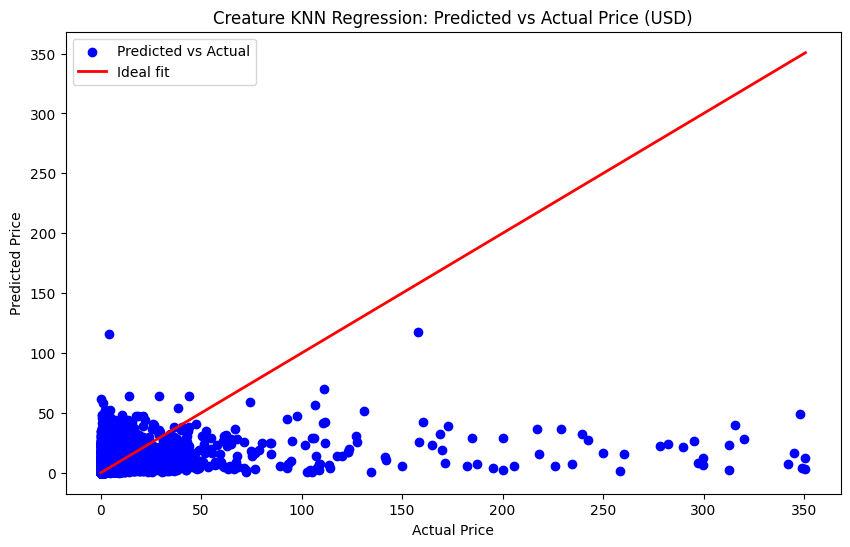

In [52]:
creat_mae, creat_mse, creat_r2 = knnReg(X_train_creat, X_test_creat, y_train_creat, y_test_creat, graphtype='Creature')

In [53]:
# all features
# keep reprints & nonreprints: 
# MAE 5.134888791632624, MSE 399.1699414075267, R2 0.04503362281067269

# commented out certain features (feature importance)
# do not filter reprints: 
# MAE 5.314887973040717, MSE 421.9506698038905, R2 -0.009466547191354868

# commented out feats, don't filter reprints, used text feats:
# MAE: 5.109530737644238, MSE: 383.1402975781447, R2: 0.08338262985615041
# ^ current best

Mean Absolute Error: 9.246097724720228   Mean Squared Error: 2334.8531815715523   R2 Score: 0.23729677281355843


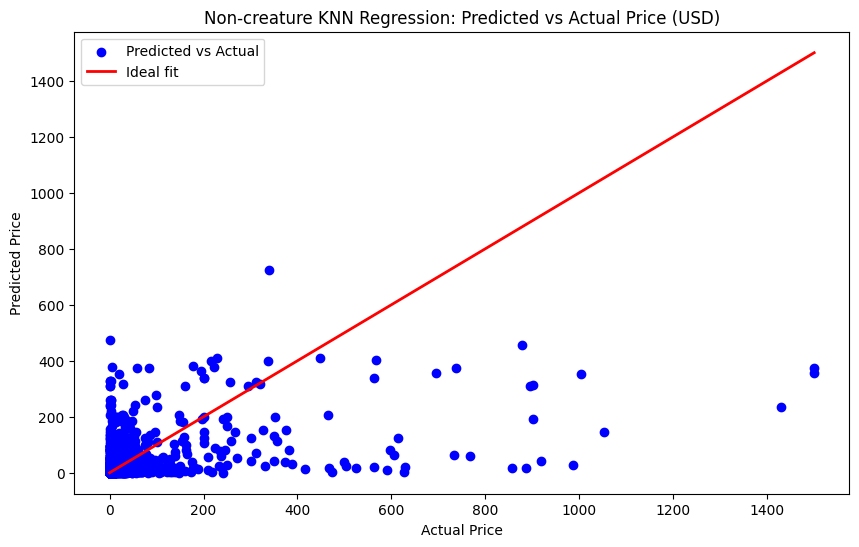

In [54]:
nc_mae, nc_mse, nc_r2 = knnReg(X_train_nc, X_test_nc, y_train_nc, y_test_nc, graphtype='Non-creature', n_neighbors=5)

In [55]:
# all features
# keep reprints/nonreprints: 
# MAE 9.79994914599423, MSE 2709.951370818073, R2 0.11476718435457445

# commented out certain features (feature importance)
# do not filter reprints: 
# MAE: 9.261276161074637, MSE: 2317.8198495657707, R2: 0.24286088168048237

# commented out feats, don't filter reprints, used text feats:
# MAE: 9.246097724720228, MSE: 2334.8531815715523, R2: 0.23729677281355843
# ^ slightly worse R2 and MSE

Mean Absolute Error: 5.945537723308231   Mean Squared Error: 104.73885664637447   R2 Score: 0.24332189584022335


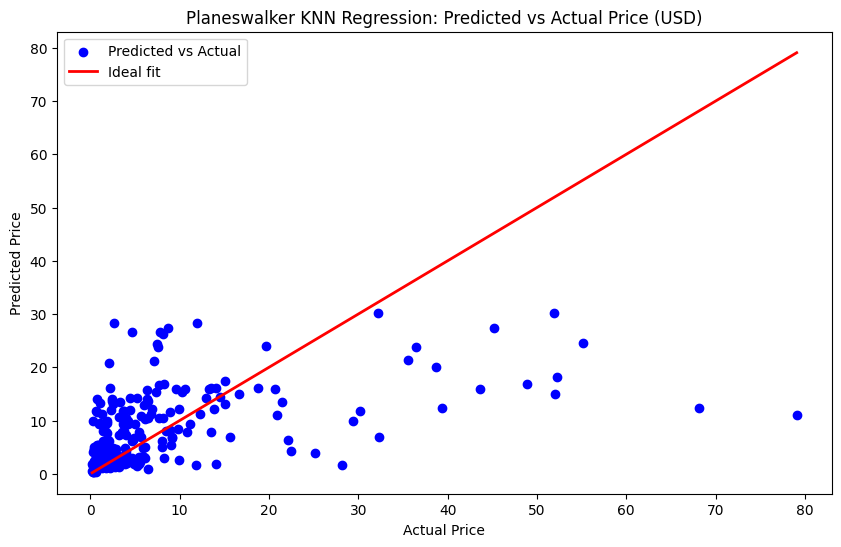

In [56]:
pw_mae, pw_mse, pw_r2 = knnReg(X_train_pw, X_test_pw, y_train_pw, y_test_pw, graphtype='Planeswalker', n_neighbors=9)

In [ ]:
# all features
# keep reprints/nonreprints: 
# MAE 6.3048959426857865, MSE 120.76230925444364, R2 0.12756165050449686

# commented out certain features (feature importance)
# do not filter reprints: 
# MAE 5.7296361004013345, MSE 105.35669393793714, R2 0.23885837613580974
# ^ current best

# commented out feats, don't filter reprints, used text feats:
# MAE: 5.800736484262265, MSE: 108.7503693972198, R2: 0.21434101939843841
# note that planeswalker_df only has a single word from tfidf